In [1]:
include("CRD_STA.jl")
include("LST_BEK.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using ProgressMeter
using DelimitedFiles

In [2]:
num = 10
c = 0.38
A0,A1,A2,A3,A4 = KEB_SpatialMode.KEB_LST_ALL("Ekman.txt",199,0,0.06,200,1,2)
nep = PEP([A0,A1,A2,A3,A4]); 
eigval,eigvec = iar(nep,σ = 0.2 , neigs = num ,maxit = 500,tol=1e-10)
eigval

SystemError: SystemError: opening file "Ekman.txt": No such file or directory

In [3]:
Tw = 1
N_cheb = 99
Mr = 0.05
gamma = 1.4
sigma = 0.72
omega = 0
R = 500
c = 0.5
be = 0.19
num = 5
Ma = Mr/R
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,1,0)
H,T = T_ca(Mr,f,q,w0,gamma,Tw)
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
lam = - (2/3) * T
kappa = (1/sigma) * T
num = 5
A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,1,0)
nep = PEP([A0,A1,A2]); 
eigval,eigvec = iar(nep , σ = c , neigs = num ,maxit = 500,tol=1e-10)
eigval

┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/rBKqA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBas

5-element Vector{ComplexF64}:
  0.4296490815872376 - 0.1088732336594928im
  0.4521336247627787 - 0.1227756481899057im
  0.4067843024068101 - 0.09424621300099352im
  0.4788233647503454 - 0.13689934623840416im
 0.38292308847342127 - 0.07466182519431844im

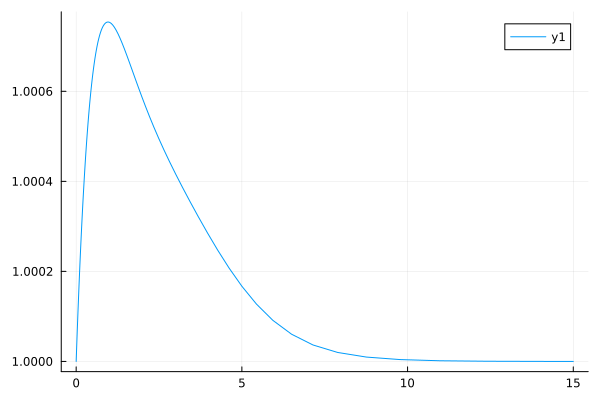

In [93]:
plot(x,T)

In [12]:
##DIRECTLY CACULATE CUR
##initial
for Tw = 1
    N_cheb = 149
    omega = 0
    Mr = 0.3
    gamma = 1.4
    sigma = 0.72
    global R = 100
    R_step = 0.1
    be1 = 0.06
    be_step = 0.0002
    c = 0.08
    num = 1
    Ro = 1
    Co = 0
    Ma = Mr/R
    
    global u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    num = 1
    global initial_i = []
    global initial_r = []
    global tempvec_i = [0 0 0 0]
    global tempvec_r = [0 0 0 0]
    global mode = 0
    writedlm("output_$Tw _ $Mr.dat",initial_i)
    writedlm("output_eig.dat",initial_r)
    A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be1,N_cheb,Ro,Co)
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = 2 ,maxit = 500,tol=1e-10)
    eigval = conj(eigval)
    if imag(eigval[1]) < 0
        for be = be1 : -be_step : -0.1

        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
        nep = PEP([A0,A1,A2]); 
        eigval,eigvec = iar(nep,σ = c , neigs = 2 ,maxit = 500,tol=1e-10)
        eigval = conj(eigval)
        point = filter(x ->  - 0.0001 < imag(x) < 0.0001, eigval)
        open("output_eig.dat", "a") do io
            write(io,"be=$be,eig=$eigval\n")
        end
        if point != []
            global initial_i = [omega R be imag(point)]
            global initial_r = [omega R be real(point)]
            break
        end
        end
    elseif imag(eigval[1]) > 0
        for be = be1 : be_step : 0.5

            A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
            nep = PEP([A0,A1,A2]); 
            eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-10)
            eigval = conj(eigval)
            point = filter(x ->  - 0.0002 < imag(x) < 0.0002, eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if point != []
                global initial_i = [omega R be imag(point)]
                global initial_r = [omega R be real(point)]
                break
            end
        end
    end
    global total_r = initial_r
    global total_i = initial_i

# CACULATE

    for be = initial_r[1,3] +  be_step  :  be_step : 0.4

        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,total_r[end,2],Ma,omega,be + 1 * be_step,N_cheb,Ro,Co)
        nep = PEP([A0,A1,A2]); 
        eigval_1,eigvec_1 = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
        eigval_1 = conj(eigval_1)
        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,total_r[end,2],Ma,omega,be + 1 * be_step,N_cheb,Ro,Co)
        nep = PEP([A0,A1,A2]); 
        eigval_2,eigvec_2 = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
        eigval_2 = conj(eigval_2)
        if (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) > 0) || (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) < 0)

        global mode = 1

        elseif (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) < 0) || (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) > 0)

        global mode = 2

        end
        
        if length(total_r[:,1]) > 2 

           grad = abs(( total_r[end,2] - total_r[end - 1,2] ) / ( total_r[end,3] - total_r[end - 1,3] ))
        else

           grad = 0

        end
        
        if mode == 1 



            for R = total_r[end,2] - 0 * grad * be_step  : -R_step : 0
                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                pre = total_r[end,4] - im * total_i[end,4]
                eigval,eigvec = iar(nep,σ = pre , neigs = num ,maxit = 500,tol=1e-10)
                eigval = conj(eigval)

                global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec_i[end- 1 ,4] * imag(eigval[1]) < 0

                    global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]]
                    global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]]

                    tempvec_i = [0 0 0 0]
                    tempvec_r = [0 0 0 0]
                    
                    break
                end
                
                if len > 30 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-15,4])

                    mode = 2
                    tempvec_i = [0 0 0 0]
                    tempvec_r = [0 0 0 0]
                    break
                    
                end
            end        
        end


        if mode == 2

            for R = total_r[end,2] + 0 * grad * be_step: R_step : 600
            
                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                eigval,eigvec = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
                eigval = conj(eigval)

                global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec_i[end - 1,4] * imag(eigval[1]) < 0

                    global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]]
                    global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]]
                    global tempvec_i = [0 0 0 0]
                    global tempvec_r = [0 0 0 0]
                    break

                end

                if len > 30 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-15,4])

                    global mode = 1
                    global tempvec_i = [0 0 0 0]
                    global tempvec_r = [0 0 0 0]
                    break
                    
                end
            end
        end

        if mode == 1
            
            for R = total_r[end,2] - 0 * grad * be_step: -R_step : 0
              
                if total_i[end,3] == be

                    break

                end 

                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                eigval,eigvec = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
                eigval = conj(eigval)
     
                global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                len = size(tempvec_i,1)

                open("output_$Tw _ $Mr.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec_i[end - 1,4] * imag(eigval[1]) < 0

                    global total_r = [total_r;[tempvec_r[end,1] tempvec_r[end,2] tempvec_r[end,3] tempvec_r[end,4]]]
                    global total_i = [total_i;[tempvec_i[end,1] tempvec_i[end,2] tempvec_i[end,3] tempvec_i[end,4]]]
                    global tempvec_i = [0 0 0 0]
                    global tempvec_r = [0 0 0 0]
                    break
                end
                
                if len > 30 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-15,4])

                global mode = 2
                global tempvec_i = [0 0 0 0]
                global tempvec_r = [0 0 0 0]
                    break
                    
                end

            end     
        end
 
        if total_i[end,2]>110 && size(total_i,1)>100
            break
        end
        # if total_i[end,2]>total_i[end-1,2]
        #     break
        # end

    end

    writedlm("Netwon_$Tw _$Mr _i.dat",total_i)
    writedlm("Netwon_$Tw _$Mr _r.dat",total_r)
    end


In [53]:
initial_r

1×4 Matrix{Float64}:
 0.0  200.0  0.043  0.0454559

In [114]:
a=[0 1 2 3]
writedlm("test.dat",a)


SystemError: SystemError: opening file "test.dat": No such file or directory